# Explore here

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

CSV_URL = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
CSV_PATH = DATA_DIR / "sales.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CSV_PATH:", CSV_PATH)


PROJECT_ROOT: /workspaces/mati-alternative-time-series-project
CSV_PATH: /workspaces/mati-alternative-time-series-project/data/sales.csv


In [5]:
df = pd.read_csv(CSV_URL)
df.to_csv(CSV_PATH, index=False)

print(df.shape)
print(df.columns.tolist())
df.head()


(366, 2)
['date', 'sales']


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [6]:
def detect_date_and_value_columns(df):
    date_candidates = []
    for c in df.columns:
        if df[c].dtype == "object" or "date" in c.lower() or "time" in c.lower() or "month" in c.lower():
            date_candidates.append(c)

    best_date = None
    best_ok = -1

    for c in date_candidates:
        parsed = pd.to_datetime(df[c], errors="coerce")
        ok = int(parsed.notna().sum())
        if ok > best_ok:
            best_ok = ok
            best_date = c

    if best_date is None:
        for c in df.columns:
            parsed = pd.to_datetime(df[c], errors="coerce")
            ok = int(parsed.notna().sum())
            if ok > best_ok:
                best_ok = ok
                best_date = c

    numeric_cols = [c for c in df.columns if c != best_date]
    best_value = None
    best_numeric_ok = -1

    for c in numeric_cols:
        s = pd.to_numeric(df[c], errors="coerce")
        ok = int(s.notna().sum())
        if ok > best_numeric_ok:
            best_numeric_ok = ok
            best_value = c

    return best_date, best_value

date_col, value_col = detect_date_and_value_columns(df)
print("date_col:", date_col)
print("value_col:", value_col)


date_col: date
value_col: sales


In [7]:
ts_df = df[[date_col, value_col]].copy()
ts_df[date_col] = pd.to_datetime(ts_df[date_col], errors="coerce")
ts_df[value_col] = pd.to_numeric(ts_df[value_col], errors="coerce")
ts_df = ts_df.dropna().sort_values(date_col)

ts_df = ts_df.set_index(date_col)
ts_df = ts_df[~ts_df.index.duplicated(keep="last")]
ts = ts_df[value_col].astype(float)

print("Rows:", ts.shape[0])
print("Date range:", ts.index.min(), "->", ts.index.max())
ts.head()


Rows: 366
Date range: 2022-09-03 17:10:08.079328 -> 2023-09-03 17:10:08.079328


date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64

Tensor (unidad mínima): 1 days 00:00:00
Frecuencia inferida: D


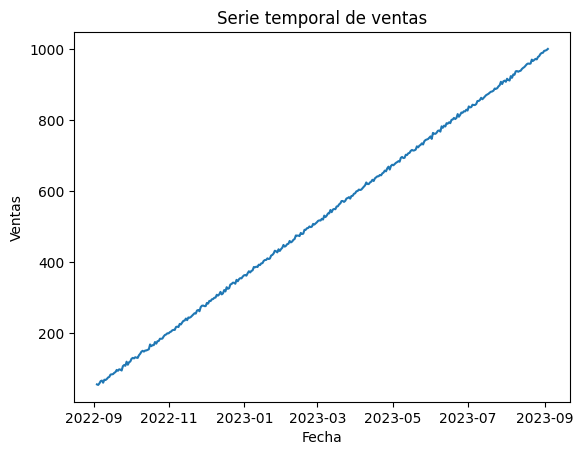

In [8]:
deltas = ts.index.to_series().diff().dropna()
tensor = deltas.mode().iloc[0] if len(deltas) > 0 else None
freq_inferred = pd.infer_freq(ts.index)

print("Tensor (unidad mínima):", tensor)
print("Frecuencia inferida:", freq_inferred)

plt.figure()
plt.plot(ts.index, ts.values)
plt.title("Serie temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()


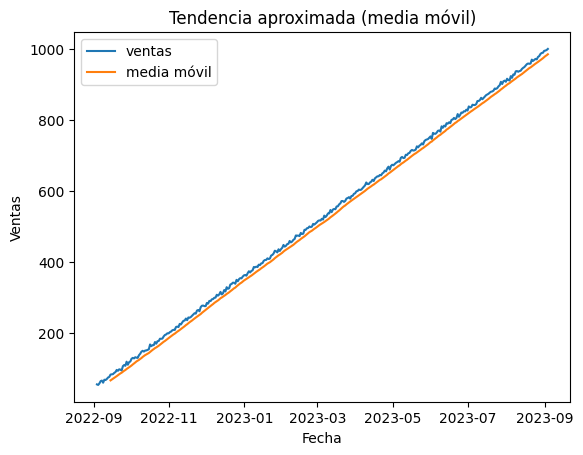

In [9]:
rolling_window = max(3, int(min(12, max(3, ts.shape[0] // 20))))
roll_mean = ts.rolling(rolling_window).mean()

plt.figure()
plt.plot(ts.index, ts.values, label="ventas")
plt.plot(roll_mean.index, roll_mean.values, label="media móvil")
plt.title("Tendencia aproximada (media móvil)")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.show()


In [10]:
def adf_test(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 10:
        return {"stat": np.nan, "pvalue": np.nan, "ok": False}

    x = x - np.mean(x)
    y = np.diff(x)
    X = x[:-1]

    denom = np.dot(X, X)
    if denom == 0:
        return {"stat": np.nan, "pvalue": np.nan, "ok": False}

    beta = np.dot(X, y) / denom
    resid = y - beta * X
    s2 = np.dot(resid, resid) / max(1, (len(resid) - 1))
    se = np.sqrt(s2 / denom)

    if se == 0:
        return {"stat": np.nan, "pvalue": np.nan, "ok": False}

    t_stat = float(beta / se)

    p_approx = 0.01 if t_stat < -3.43 else (0.05 if t_stat < -2.86 else (0.10 if t_stat < -2.57 else 0.50))

    return {"stat": t_stat, "pvalue": p_approx, "ok": True}

adf_res = adf_test(ts.values)
print("ADF statistic (aprox):", adf_res["stat"])
print("ADF p-value (aprox):", adf_res["pvalue"])
print("Estacionaria? (aprox)", adf_res["pvalue"] < 0.05)


ADF statistic (aprox): -0.06748721771412035
ADF p-value (aprox): 0.5
Estacionaria? (aprox) False


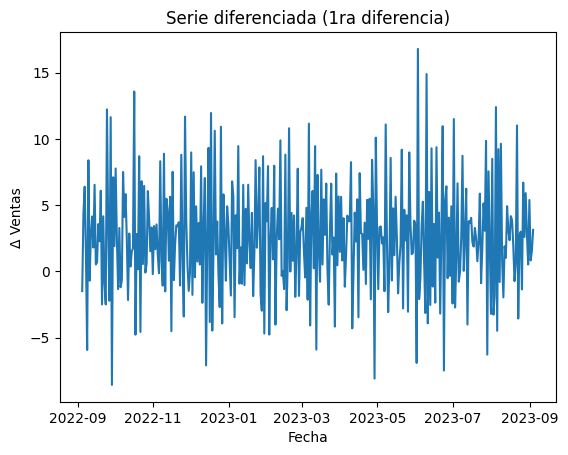

ADF p-value (aprox, diff1): 0.01


In [11]:
diff1 = ts.diff().dropna()

plt.figure()
plt.plot(diff1.index, diff1.values)
plt.title("Serie diferenciada (1ra diferencia)")
plt.xlabel("Fecha")
plt.ylabel("Δ Ventas")
plt.show()

adf_res_d1 = adf_test(diff1.values)
print("ADF p-value (aprox, diff1):", adf_res_d1["pvalue"])


In [12]:
n = len(ts)
test_size = max(1, int(round(n * 0.2)))

train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print("Train:", train.shape, train.index.min(), "->", train.index.max())
print("Test:", test.shape, test.index.min(), "->", test.index.max())


Train: (293,) 2022-09-03 17:10:08.079328 -> 2023-06-22 17:10:08.079328
Test: (73,) 2023-06-23 17:10:08.079328 -> 2023-09-03 17:10:08.079328


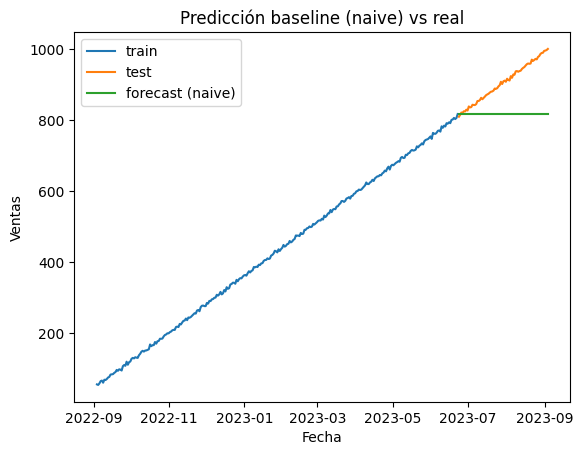

In [13]:
def naive_forecast_last_value(train_series, steps):
    last = float(train_series.iloc[-1])
    return np.array([last] * int(steps), dtype=float)

forecast = naive_forecast_last_value(train, len(test))
forecast = pd.Series(forecast, index=test.index)

plt.figure()
plt.plot(train.index, train.values, label="train")
plt.plot(test.index, test.values, label="test")
plt.plot(forecast.index, forecast.values, label="forecast (naive)")
plt.title("Predicción baseline (naive) vs real")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.show()


In [14]:
mae = float(mean_absolute_error(test.values, forecast.values))
rmse = float(np.sqrt(mean_squared_error(test.values, forecast.values)))

eps = 1e-9
mape = float(np.mean(np.abs((test.values - forecast.values) / (np.abs(test.values) + eps))) * 100.0)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE (%):", mape)


MAE: 89.15699837423047
RMSE: 104.48821213288403
MAPE (%): 9.51286844842773


In [15]:
model_path = MODELS_DIR / "sales_baseline_naive.joblib"
meta_path = PROCESSED_DIR / "sales_series_meta.joblib"

joblib.dump({"type": "naive_last_value"}, model_path)

meta = {
    "date_col": date_col,
    "value_col": value_col,
    "tensor": str(tensor),
    "freq_inferred": freq_inferred,
    "train_start": str(train.index.min()),
    "train_end": str(train.index.max()),
    "test_start": str(test.index.min()),
    "test_end": str(test.index.max()),
    "mae": mae,
    "rmse": rmse,
    "mape": mape
}

joblib.dump(meta, meta_path)

print("Modelo baseline guardado en:", model_path)
print("Meta guardada en:", meta_path)


Modelo baseline guardado en: /workspaces/mati-alternative-time-series-project/models/sales_baseline_naive.joblib
Meta guardada en: /workspaces/mati-alternative-time-series-project/data/processed/sales_series_meta.joblib
